<a href="https://colab.research.google.com/github/Rabidhau/assessment0/blob/main/wps6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow
# Define dataset paths
test_dir = "/content/drive/MyDrive/Ai/DevanagariHandwrittenDigitDataset/Test"
train_dir = "/content/drive/MyDrive/Ai/DevanagariHandwrittenDigitDataset/Train"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      label = class_map[class_name]
      for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Load image using PIL
        img = Image.open(img_path).convert("L") # Convert to grayscale
        img = img.resize((img_width, img_height)) # Resize to (28,28)
        img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
        images.append(img)
        labels.append(label)
  return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Split training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

def add_noise(imgs, noise_type='gaussian'):
    noisy_imgs = imgs.copy()
    if noise_type == 'gaussian':
        noise = np.random.normal(0, 0.1, imgs.shape)
        noisy_imgs += noise
    elif noise_type == 's&p':
        s_vs_p = 0.5
        amount = 0.02
        out = np.copy(imgs)
        # Salt
        num_salt = np.ceil(amount * imgs.size * s_vs_p)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in imgs.shape]
        out[tuple(coords)] = 1
        # Pepper
        num_pepper = np.ceil(amount * imgs.size * (1. - s_vs_p))
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in imgs.shape]
        out[tuple(coords)] = 0
        noisy_imgs = out
    return np.clip(noisy_imgs, 0., 1.)

x_train_noisy = add_noise(x_train, 'gaussian')
x_val_noisy = add_noise(x_val, 'gaussian')


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 43s 340ms/step - loss: 0.3560 - val_loss: 0.1681
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 336ms/step - loss: 0.1638 - val_loss: 0.1580
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 349ms/step - loss: 0.1568 - val_loss: 0.1542
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 342ms/step - loss: 0.1527 - val_loss: 0.1523
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 82s 343ms/step - loss: 0.1512 - val_loss: 0.1504
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 41s 343ms/step - loss: 0.1499 - val_loss: 0.1494
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 338ms/step - loss: 0.1488 - val_loss: 0.1488
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 343ms/step - loss: 0.1480 - val_loss: 0.1481
Epoch 9/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 84s 359ms/step - loss: 0.1477 - val_loss: 0.1475
Epoch 10/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 342ms/step - loss: 0.1474 - val_loss: 0.1479
Epoch 11/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - loss: 0.1464 - val_loss: 0.1467
Epoch 12/20
120/120

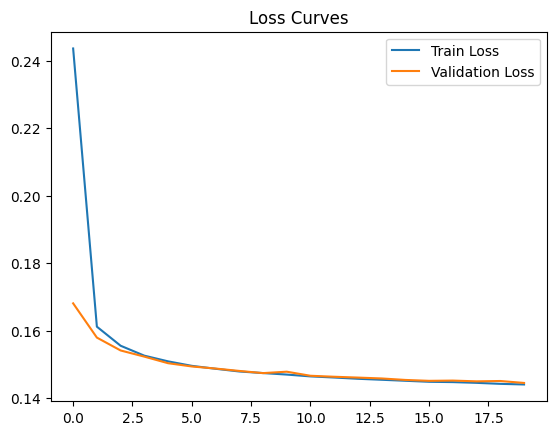

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


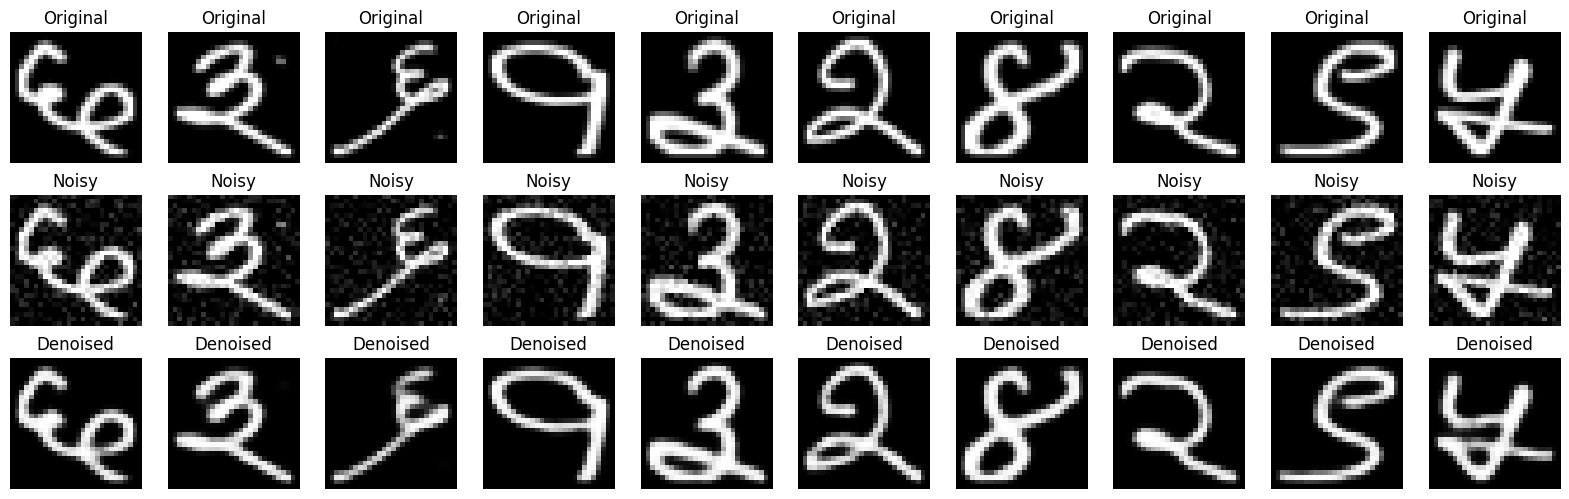

In [ ]:
decoded_imgs = autoencoder.predict(x_val_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_val[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_val_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()
